In [18]:
import sys
!{sys.executable} -m pip install wrds --quiet

import wrds
import pandas as pd

In [20]:
db = wrds.Connection()

Enter your WRDS username [betty]: wjfyyawbxx
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  y


Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


In [21]:
pip install wrds pandas numpy

Note: you may need to restart the kernel to use updated packages.


In [23]:
import wrds
import pandas as pd
import numpy as np

# ==========================================
# 1. Connect to WRDS
# ==========================================
# Note: You will be prompted to enter your WRDS username and password in the terminal.
db = wrds.Connection()

# ==========================================
# 2. Define SQL Query
# ==========================================
# Compustat Variable Definitions:
# gvkey   : Company Key
# datadate: Data Date
# fyear   : Fiscal Year
# tic     : Ticker Symbol
# revt    : Revenue (Total)
# cogs    : Cost of Goods Sold
# ni      : Net Income
# invt    : Inventory (Total)
# xrd     : Research and Development Expense

sql_query = """
SELECT 
    gvkey, 
    datadate, 
    fyear, 
    tic, 
    revt,  -- Revenue
    cogs,  -- Cost of Goods Sold
    ni,    -- Net Income
    invt,  -- Inventory
    xrd    -- R&D Expenses
FROM comp.funda
WHERE tic IN ('TSLA', 'TM')  -- Tesla and Toyota
AND fyear >= 2020            -- Fiscal Year >= 2020
AND fyear <= 2025            -- Fiscal Year <= 2025
AND indfmt = 'INDL'          -- Industrial Format
AND datafmt = 'STD'          -- Standard Data
AND popsrc = 'D'             -- Data Source
AND consol = 'C'             -- Consolidated Statements
ORDER BY tic, fyear
"""

# ==========================================
# 3. Execute Query and Data Cleaning
# ==========================================
print("Fetching data from WRDS...")
try:
    # Execute the SQL query using the db connection
    raw_data = db.raw_sql(sql_query)
    
    # Sort data by Ticker and Fiscal Year
    raw_data = raw_data.sort_values(by=['tic', 'fyear'])
    
    # Check if data is empty
    if raw_data.empty:
        print("Warning: No data found. Please check SQL conditions or network connection.")
    else:
        print(f"Successfully retrieved {len(raw_data)} rows of data.")

except Exception as e:
    print(f"Error during query: {e}")

# ==========================================
# 4. Calculate Financial Metrics
# ==========================================
def calculate_metrics(df):
    """
    Calculate Gross Margin, Net Margin, Days Sales in Inventory (DSI), and R&D Intensity
    """
    # Create a copy to avoid modifying the original dataframe
    df_calc = df.copy()
    
    # --- 1. Gross Margin ---
    # Formula: (Revenue - Cost of Goods Sold) / Revenue
    df_calc['Gross_Margin'] = (df_calc['revt'] - df_calc['cogs']) / df_calc['revt']
    
    # --- 2. Net Margin ---
    # Formula: Net Income / Revenue
    df_calc['Net_Margin'] = df_calc['ni'] / df_calc['revt']
    
    # --- 3. Days Sales in Inventory (DSI) ---
    # Formula: (Inventory / Cost of Goods Sold) * 365
    # Note: Using ending inventory for simplification
    # Replace cogs = 0 with NaN to avoid division by zero
    safe_cogs = df_calc['cogs'].replace(0, np.nan)
    df_calc['DSI'] = (df_calc['invt'] / safe_cogs) * 365
    
    # --- 4. R&D Intensity ---
    # Formula: R&D Expenses / Revenue
    df_calc['RD_Intensity'] = df_calc['xrd'] / df_calc['revt']
    
    return df_calc

# Execute calculation
if not raw_data.empty:
    final_df = calculate_metrics(raw_data)
    
    # ==========================================
    # 5. Format Output
    # ==========================================
    # Select columns to display
    display_cols = [
        'tic', 'fyear', 'revt', 'ni', 
        'Gross_Margin', 'Net_Margin', 'DSI', 'RD_Intensity'
    ]
    
    # Format float numbers (4 decimal places)
    pd.set_option('display.float_format', '{:.4f}'.format)
    
    print("\nFinancial Metrics Comparison: Tesla vs Toyota (2020-2025):")
    print("-" * 80)
    print(final_df[display_cols])
    
    # Optional: Save to CSV
    # final_df.to_csv('wrds_auto_analysis.csv', index=False)

Enter your WRDS username [betty]: wjfyyawbxx
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  y


Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
Fetching data from WRDS...
Successfully retrieved 11 rows of data.

Financial Metrics Comparison: Tesla vs Toyota (2020-2025):
--------------------------------------------------------------------------------
     tic  fyear        revt         ni  Gross_Margin  Net_Margin     DSI  \
0     TM   2020 246059.0000 20300.0000        0.2380      0.0825 50.8314   
1     TM   2021 258406.0000 23470.0000        0.2484      0.0908 59.1361   
2     TM   2022 279487.0000 18440.0000        0.2248      0.0660 53.9327   
3     TM   2023 298146.0000 32693.0000        0.2540      0.1097 49.9688   
4     TM   2024 320782.0000 31821.0000        0.2463      0.0992 46.3532   
5   TSLA   2020  31536.0000   721.0000        0.2913      0.0229 66.9708   
6   TSLA   2021  53823.0000  5519.0000        0.3069      0.1025 56.3262   
7   TSLA   2022  81462.0000 12556.

In [24]:
import wrds
import pandas as pd

# ==========================================
# 1. Connect to WRDS
# ==========================================
# If you just created the .pgpass file, it might login automatically this time.
db = wrds.Connection()

# ==========================================
# 2. Define SQL Query (Enriched Data)
# ==========================================
# Added 'at' (Total Assets) and 'che' (Cash & Equivalents) for a more complete report
sql_query = """
SELECT 
    gvkey, 
    datadate, 
    fyear, 
    tic, 
    revt,  -- Revenue
    cogs,  -- Cost of Goods Sold
    ni,    -- Net Income
    invt,  -- Inventory
    xrd,   -- R&D Expenses
    at,    -- Total Assets (新增：总资产)
    che    -- Cash & Equivalents (新增：现金及等价物)
FROM comp.funda
WHERE tic IN ('TSLA', 'TM')  -- Tesla and Toyota
AND fyear >= 2020            -- Fiscal Year >= 2020
AND fyear <= 2025            -- Fiscal Year <= 2025
AND indfmt = 'INDL'          -- Industrial Format
AND datafmt = 'STD'          -- Standard Data
AND popsrc = 'D'             -- Data Source
AND consol = 'C'             -- Consolidated Statements
ORDER BY tic, fyear
"""

# ==========================================
# 3. Execute Query
# ==========================================
print("Fetching data from WRDS...")
try:
    df = db.raw_sql(sql_query)
    df = df['tic', 'fyear', 'revt', 'cogs', 'ni', 'invt', 'xrd', 'at', 'che'] # Select specific columns to keep it clean
    df = df.sort_values(by=['tic', 'fyear'])
    
    if df.empty:
        print("No data found.")
    else:
        print(f"Successfully retrieved {len(df)} rows.")

except Exception as e:
    print(f"Error: {e}")
    # Stop execution if query fails
    exit()

# ==========================================
# 4. Save to Files (CSV & Excel)
# ==========================================
# Define filenames
csv_filename = 'TSLA_TM_Financial_Data_2020_2025.csv'
excel_filename = 'TSLA_TM_Financial_Data_2020_2025.xlsx'

try:
    # Save as CSV
    df.to_csv(csv_filename, index=False)
    print(f"✅ CSV file saved: {csv_filename}")

    # Save as Excel (Requires openpyxl: pip install openpyxl)
    try:
        df.to_excel(excel_filename, index=False)
        print(f"✅ Excel file saved: {excel_filename}")
    except ImportError:
        print("⚠️ 'openpyxl' library not found. Only CSV was saved.")
        print("   (Install it using: pip install openpyxl)")

except Exception as e:
    print(f"Error saving files: {e}")

# ==========================================
# 5. Preview Data
# ==========================================
print("\nData Preview (First 5 rows):")
print(df.head())

Enter your WRDS username [betty]: wjfyyawbxx
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  y


Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
Fetching data from WRDS...
Error: ('tic', 'fyear', 'revt', 'cogs', 'ni', 'invt', 'xrd', 'at', 'che')
✅ CSV file saved: TSLA_TM_Financial_Data_2020_2025.csv
✅ Excel file saved: TSLA_TM_Financial_Data_2020_2025.xlsx

Data Preview (First 5 rows):
    gvkey    datadate  fyear tic        revt        cogs         ni  \
0  019661  2021-03-31   2020  TM 246059.0000 187500.0000 20300.0000   
1  019661  2022-03-31   2021  TM 258406.0000 194227.0000 23470.0000   
2  019661  2023-03-31   2022  TM 279487.0000 216654.0000 18440.0000   
3  019661  2024-03-31   2023  TM 298146.0000 222409.0000 32693.0000   
4  019661  2025-03-31   2024  TM 320782.0000 241789.0000 31821.0000   

        invt       xrd          at        che  
0 26112.0000 9859.0000 562983.0000 46119.0000  
1 31468.0000 9258.0000 557408.0000 50346.0000  
2 32013.0000 9340.0000 558933.0000 

In [1]:
import pandas as pd

df = pd.read_csv('TSLA_TM_Financial_Data_2020_2025.csv')

df['Gross_Margin'] = (df['revt'] - df['cogs']) / df['revt']
df['Net_Margin'] = df['ni'] / df['revt']
df['DSI'] = (df['invt'] / df['cogs']) * 365

df.to_csv('cleaned_data.csv', index=False)
print("Cleaning completed! cleaned_data.csv generated")

Cleaning completed! cleaned_data.csv generated


In [2]:
import wrds
import pandas as pd

db = wrds.Connection()

sql_query = """
SELECT 
    gvkey, 
    datadate, 
    fyear, 
    tic, 
    conm,
    revt,
    cogs,
    xsga,
    xrd,
    xint,
    txt,
    ni,
    at,
    lt,
    ceq,
    che,
    rect,
    invt,
    ppent,
    dltt,
    oancf,
    fincf,
    ivncf,
    capx
FROM comp.funda
WHERE sic >= 3710 AND sic < 3720
AND fyear >= 2020
AND fyear <= 2025
AND indfmt = 'INDL'
AND datafmt = 'STD'
AND popsrc = 'D'
AND consol = 'C'
ORDER BY tic, fyear
"""

try:
    df = db.raw_sql(sql_query)
    df = df.sort_values(['gvkey', 'fyear', 'datadate'], ascending=[True, True, False])
    df = df.drop_duplicates(subset=['gvkey', 'fyear'], keep='first')
    print(f"Successfully retrieved {len(df)} rows for {df['tic'].nunique()} unique companies.")

except Exception as e:
    print(f"Error: {e}")
    exit()

csv_filename = 'Auto_Industry_Comprehensive_Data.csv'
excel_filename = 'Auto_Industry_Comprehensive_Data.xlsx'

try:
    df.to_csv(csv_filename, index=False)
    print(f"CSV saved: {csv_filename}")
    
    try:
        df.to_excel(excel_filename, index=False)
        print(f"Excel saved: {excel_filename}")
    except ImportError:
        print("'openpyxl' missing. Install with: pip install openpyxl")

except Exception as e:
    print(f"Error saving files: {e}")

print("\nList of Companies Retrieved:")

if 'conm' in df.columns:
    print(df[['tic', 'conm']].drop_duplicates().sort_values('tic').to_string(index=False))
else:
    print("Company Name (conm) not found. Showing tickers only:")
    print(df[['tic']].drop_duplicates().sort_values('tic').to_string(index=False))

print("\nData Columns Available:")
print(df.columns.tolist())

Enter your WRDS username [betty]: wjfyyawbxx
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  y


Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
Error: (psycopg2.errors.UndefinedColumn) column "sic" does not exist
LINE 28: WHERE sic >= 3710 AND sic < 3720
               ^

[SQL: 
SELECT 
    gvkey, 
    datadate, 
    fyear, 
    tic, 
    conm,
    revt,
    cogs,
    xsga,
    xrd,
    xint,
    txt,
    ni,
    at,
    lt,
    ceq,
    che,
    rect,
    invt,
    ppent,
    dltt,
    oancf,
    fincf,
    ivncf,
    capx
FROM comp.funda
WHERE sic >= 3710 AND sic < 3720
AND fyear >= 2020
AND fyear <= 2025
AND indfmt = 'INDL'
AND datafmt = 'STD'
AND popsrc = 'D'
AND consol = 'C'
ORDER BY tic, fyear
]
(Background on this error at: https://sqlalche.me/e/20/f405)
CSV saved: Auto_Industry_Comprehensive_Data.csv
Excel saved: Auto_Industry_Comprehensive_Data.xlsx

List of Companies Retrieved:
Company Name (conm) not found. Showing tickers only:
 tic
  TM
TSLA

Data Columns Available:


In [1]:
import pandas as pd
import numpy as np

# ==========================================
# 1. Load the data you just downloaded
# ==========================================
filename = 'Auto_Industry_Comprehensive_Data.csv'

try:
    df = pd.read_csv(filename)
    print(f"✅ Data loaded successfully: {filename}")
    print(f"   Total rows: {len(df)}")
except FileNotFoundError:
    print(f"❌ Error: File '{filename}' not found.")
    print("   Please ensure the CSV file is in the current folder.")
    import sys
    sys.exit()

# ==========================================
# 2. Data Cleaning & Financial Ratio Calculation
# ==========================================
# Replace infinite values with NaN to avoid calculation errors
df = df.replace([np.inf, -np.inf], np.nan)

# --- A. Gross Margin (%) = (Revenue - COGS) / Revenue ---
# Using WRDS fields: revt (Revenue), cogs (Cost of Goods Sold)
df['Gross_Margin'] = (df['revt'] - df['cogs']) / df['revt']

# --- B. Net Margin (%) = Net Income / Revenue ---
# Using WRDS fields: ni (Net Income)
df['Net_Margin'] = df['ni'] / df['revt']

# --- C. Inventory Turnover Days (DSI) = (Inventory / COGS) * 365 ---
# Using WRDS fields: invt (Inventory)
# Note: We replace 0 with NaN in COGS to avoid division by zero
df['DSI'] = (df['invt'] / df['cogs'].replace(0, np.nan)) * 365

# --- D. Asset Turnover = Revenue / Total Assets ---
# Using WRDS fields: at (Total Assets)
df['Asset_Turnover'] = df['revt'] / df['at']

# ==========================================
# 3. Formatting
# ==========================================
# Round to 4 decimal places for ratios, 2 for days
df['Gross_Margin'] = df['Gross_Margin'].round(4)
df['Net_Margin'] = df['Net_Margin'].round(4)
df['DSI'] = df['DSI'].round(2)
df['Asset_Turnover'] = df['Asset_Turnover'].round(4)

# ==========================================
# 4. Save the cleaned data for Streamlit
# ==========================================
output_file = 'cleaned_data.csv'
df.to_csv(output_file, index=False)
print(f"✅ Calculations complete. Saved to: {output_file}")

# ==========================================
# 5. Preview the results
# ==========================================
print("\n📊 Preview of Calculated Ratios (First 10 rows):")
# Display only relevant columns for checking
cols_to_show = ['tic', 'fyear', 'Gross_Margin', 'Net_Margin', 'DSI', 'Asset_Turnover']
print(df[cols_to_show].head(10))

✅ Data loaded successfully: Auto_Industry_Comprehensive_Data.csv
   Total rows: 11
✅ Calculations complete. Saved to: cleaned_data.csv

📊 Preview of Calculated Ratios (First 10 rows):
    tic  fyear  Gross_Margin  Net_Margin    DSI  Asset_Turnover
0    TM   2020        0.2380      0.0825  50.83          0.4371
1    TM   2021        0.2484      0.0908  59.14          0.4636
2    TM   2022        0.2248      0.0660  53.93          0.5000
3    TM   2023        0.2540      0.1097  49.97          0.5004
4    TM   2024        0.2463      0.0992  46.35          0.5132
5  TSLA   2020        0.2913      0.0229  66.97          0.6047
6  TSLA   2021        0.3069      0.1025  56.33          0.8663
7  TSLA   2022        0.3020      0.1541  82.41          0.9894
8  TSLA   2023        0.2307      0.1550  66.81          0.9077
9  TSLA   2024        0.2336      0.0726  58.58          0.8003


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.switch_backend('Agg')
sns.set_style("whitegrid")

file_path = 'TSLA_TM_Financial_Data_2020_2025.csv'

try:
    df = pd.read_csv(file_path)
except FileNotFoundError:
    exit()

target_companies = ['TSLA', 'TM']
df_filtered = df[df['tic'].isin(target_companies)]

if 'ni' in df_filtered.columns:
    df_plot = df_filtered[['tic', 'fyear', 'ni']].dropna()
    df_plot = df_plot.sort_values('fyear')
    df_plot['Net_Income_Millions'] = df_plot['ni'] / 1000

    plt.figure(figsize=(12, 6))
    
    sns.lineplot(
        data=df_plot, 
        x='fyear', 
        y='Net_Income_Millions', 
        hue='tic', 
        marker='o', 
        linewidth=2.5, 
        palette={'TSLA': 'orange', 'TM': 'lightblue'}, 
        markersize=8
    )

    plt.title('Tesla (TSLA) vs Toyota (TM): Net Income Trend (2020-2025)', fontsize=18, fontweight='bold')
    plt.ylabel('Net Income (Millions USD)', fontsize=14)
    plt.xlabel('Fiscal Year', fontsize=14)
    plt.legend(title='Company', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)

    for i, row in df_plot.iterrows():
        plt.text(row['fyear'], row['Net_Income_Millions'], f"{row['Net_Income_Millions']:.0f}", 
                 ha='center', va='bottom' if row['tic'] == 'TSLA' else 'top', fontsize=9)

    plt.tight_layout()
    plt.savefig('Figure1_Net_Income_Trend.png', dpi=300, bbox_inches='tight')
    plt.close()

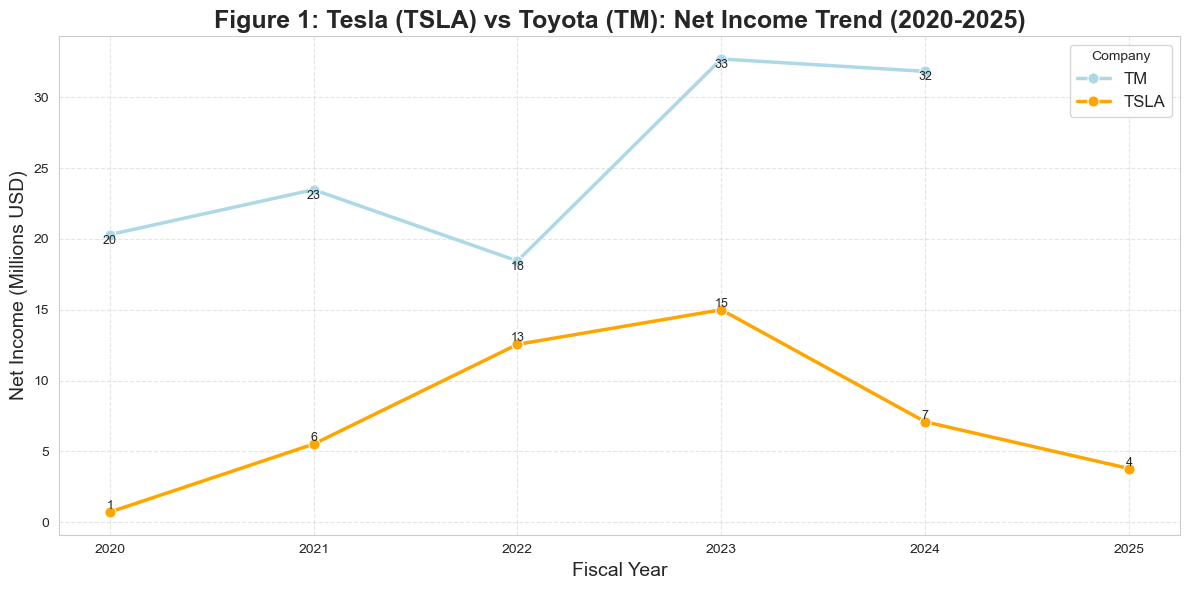

In [12]:
%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

file_path = 'TSLA_TM_Financial_Data_2020_2025.csv'

try:
    df = pd.read_csv(file_path)
except FileNotFoundError:
    exit()

target_companies = ['TSLA', 'TM']
df_filtered = df[df['tic'].isin(target_companies)]

if 'ni' in df_filtered.columns:
    df_plot = df_filtered[['tic', 'fyear', 'ni']].dropna()
    df_plot = df_plot.sort_values('fyear')
    df_plot['Net_Income_Millions'] = df_plot['ni'] / 1000

    plt.figure(figsize=(12, 6))
    
    sns.lineplot(
        data=df_plot, 
        x='fyear', 
        y='Net_Income_Millions', 
        hue='tic', 
        marker='o', 
        linewidth=2.5, 
        palette={'TSLA': 'orange', 'TM': 'lightblue'}, 
        markersize=8
    )

    plt.title('Figure 1: Tesla (TSLA) vs Toyota (TM): Net Income Trend (2020-2025)', fontsize=18, fontweight='bold')
    plt.ylabel('Net Income (Millions USD)', fontsize=14)
    plt.xlabel('Fiscal Year', fontsize=14)
    plt.legend(title='Company', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)

    for i, row in df_plot.iterrows():
        plt.text(row['fyear'], row['Net_Income_Millions'], f"{row['Net_Income_Millions']:.0f}", 
                 ha='center', va='bottom' if row['tic'] == 'TSLA' else 'top', fontsize=9)

    plt.tight_layout()
    plt.savefig('Figure1_Net_Income_Trend.png', dpi=300)
    plt.show()

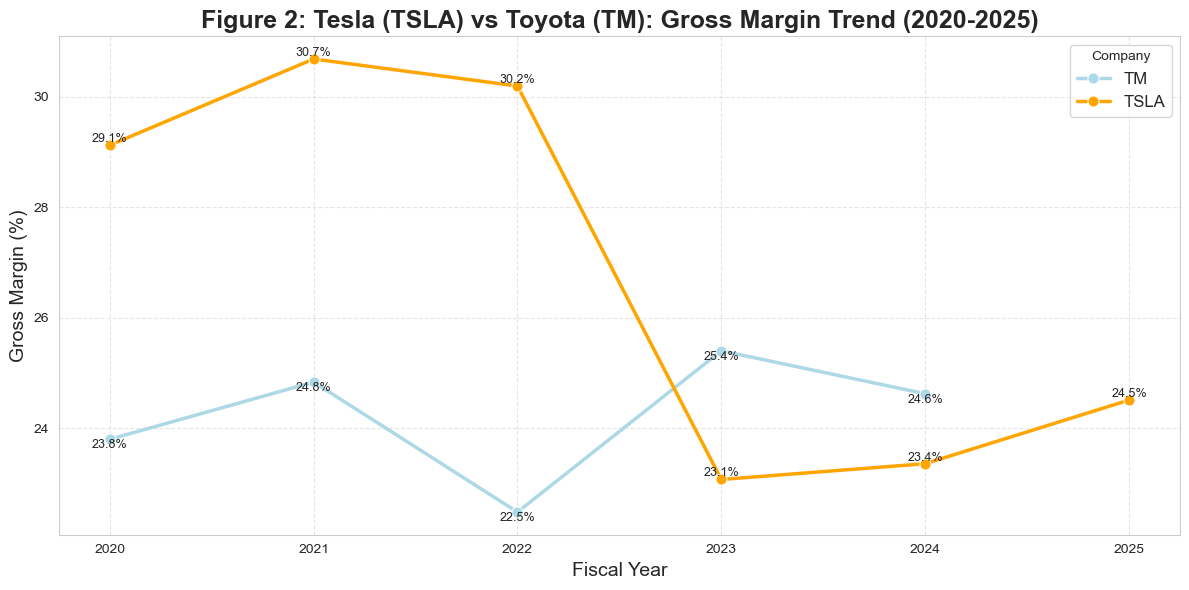

In [13]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

file_path = 'TSLA_TM_Financial_Data_2020_2025.csv'

try:
    df = pd.read_csv(file_path)
except FileNotFoundError:
    exit()

target_companies = ['TSLA', 'TM']
df_filtered = df[df['tic'].isin(target_companies)]

required_cols = ['revt', 'cogs']
missing_cols = [col for col in required_cols if col not in df_filtered.columns]

if not missing_cols:
    df_filtered['gross_margin'] = (df_filtered['revt'] - df_filtered['cogs']) / df_filtered['revt'] * 100
    df_plot = df_filtered[df_filtered['fyear'].between(2020, 2025)]
    df_plot = df_plot[['tic', 'fyear', 'gross_margin']].dropna().sort_values('fyear')

    plt.figure(figsize=(12, 6))
    
    sns.lineplot(
        data=df_plot, 
        x='fyear', 
        y='gross_margin', 
        hue='tic', 
        marker='o', 
        linewidth=2.5, 
        palette={'TSLA': 'orange', 'TM': 'lightblue'}, 
        markersize=8
    )

    plt.title('Figure 2: Tesla (TSLA) vs Toyota (TM): Gross Margin Trend (2020-2025)', fontsize=18, fontweight='bold')
    plt.ylabel('Gross Margin (%)', fontsize=14)
    plt.xlabel('Fiscal Year', fontsize=14)
    plt.legend(title='Company', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)

    for i, row in df_plot.iterrows():
        plt.text(row['fyear'], row['gross_margin'], f"{row['gross_margin']:.1f}%", 
                 ha='center', va='bottom' if row['tic'] == 'TSLA' else 'top', fontsize=9)

    plt.tight_layout()
    plt.savefig('Figure2_Gross_Margin_Trend.png', dpi=300)
    plt.show()

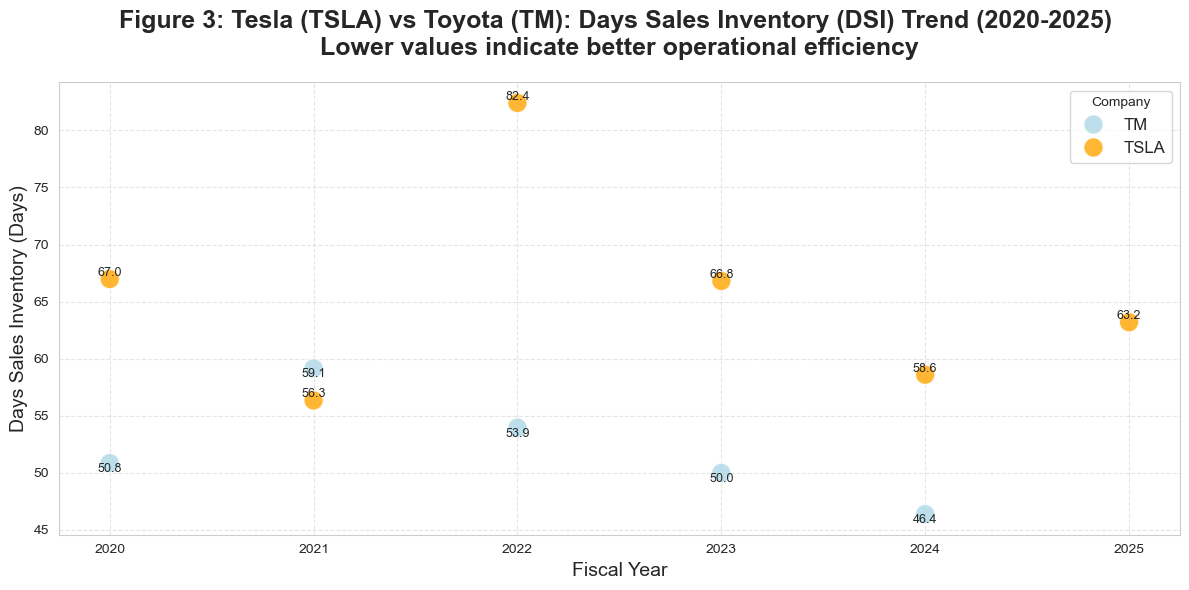

In [1]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

file_path = 'TSLA_TM_Financial_Data_2020_2025.csv'

try:
    df = pd.read_csv(file_path)
except FileNotFoundError:
    exit()

target_companies = ['TSLA', 'TM']
df_filtered = df[df['tic'].isin(target_companies)]

required_cols = ['invt', 'cogs']
missing_cols = [col for col in required_cols if col not in df_filtered.columns]

if not missing_cols:
    df_filtered['dsi'] = (df_filtered['invt'] / df_filtered['cogs']) * 365
    df_plot = df_filtered[df_filtered['fyear'].between(2020, 2025)]
    df_plot = df_plot[['tic', 'fyear', 'dsi']].dropna().sort_values('fyear')

    plt.figure(figsize=(12, 6))
    
    sns.scatterplot(
        data=df_plot, 
        x='fyear', 
        y='dsi', 
        hue='tic', 
        s=200,  # 点大小
        alpha=0.8,
        palette={'TSLA': 'orange', 'TM': 'lightblue'}
    )

    plt.title('Figure 3: Tesla (TSLA) vs Toyota (TM): Days Sales Inventory (DSI) Trend (2020-2025) \nLower values indicate better operational efficiency', 
              fontsize=18, fontweight='bold', pad=20)
    
    plt.ylabel('Days Sales Inventory (Days)', fontsize=14)
    plt.xlabel('Fiscal Year', fontsize=14)
    plt.legend(title='Company', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)

    for i, row in df_plot.iterrows():
        plt.text(row['fyear'], row['dsi'], f"{row['dsi']:.1f}", 
                 ha='center', va='bottom' if row['tic'] == 'TSLA' else 'top', fontsize=9)

    plt.tight_layout()
    plt.savefig('Figure3_DSI_Trend.png', dpi=300)
    plt.show()

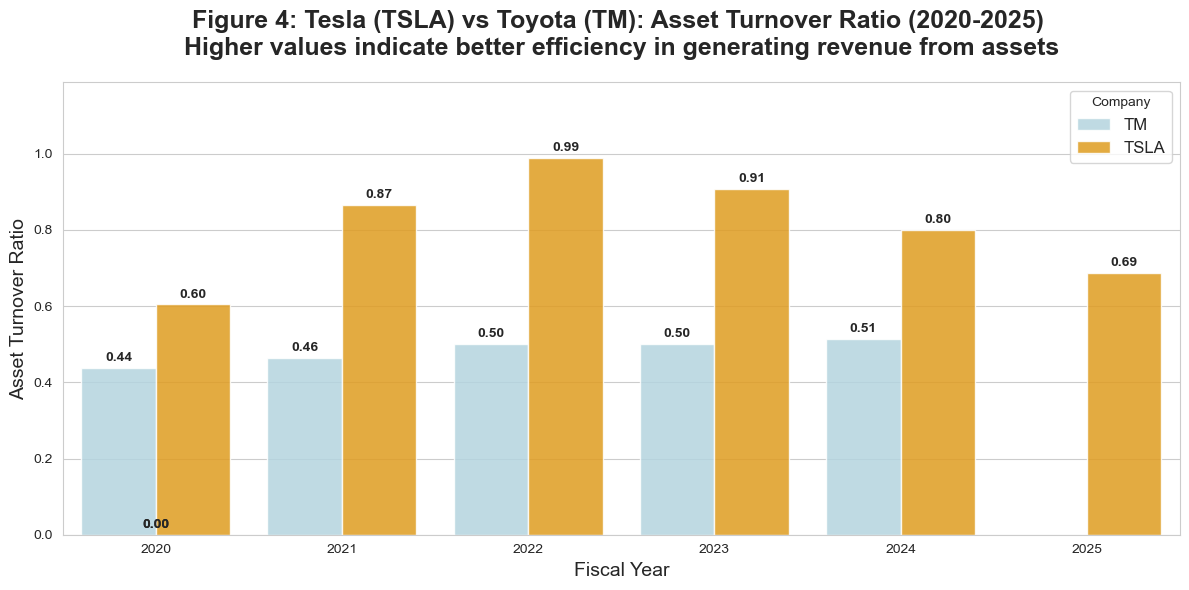

In [15]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

file_path = 'TSLA_TM_Financial_Data_2020_2025.csv'

try:
    df = pd.read_csv(file_path)
except FileNotFoundError:
    exit()

target_companies = ['TSLA', 'TM']
df_filtered = df[df['tic'].isin(target_companies)]

required_cols = ['revt', 'at']
missing_cols = [col for col in required_cols if col not in df_filtered.columns]

if not missing_cols:
    df_filtered['asset_turnover'] = df_filtered['revt'] / df_filtered['at']
    df_plot = df_filtered[df_filtered['fyear'].between(2020, 2025)]
    df_plot = df_plot[['tic', 'fyear', 'asset_turnover']].dropna().sort_values('fyear')

    plt.figure(figsize=(12, 6))

    ax = sns.barplot(
        data=df_plot,
        x='fyear',
        y='asset_turnover',
        hue='tic',
        palette={'TSLA': 'orange', 'TM': 'lightblue'},
        alpha=0.85
    )

    plt.title('Figure 4: Tesla (TSLA) vs Toyota (TM): Asset Turnover Ratio (2020-2025) \nHigher values indicate better efficiency in generating revenue from assets',
              fontsize=18, fontweight='bold', pad=20)

    plt.ylabel('Asset Turnover Ratio', fontsize=14)
    plt.xlabel('Fiscal Year', fontsize=14)
    plt.legend(title='Company', fontsize=12)
    plt.ylim(0, df_plot['asset_turnover'].max() * 1.2)

    for p in ax.patches:
        height = p.get_height()
        if not pd.isna(height):
            ax.text(p.get_x() + p.get_width() / 2., height + 0.01,
                    f'{height:.2f}',
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.savefig('Figure4_Asset_Turnover.png', dpi=300)
    plt.show()

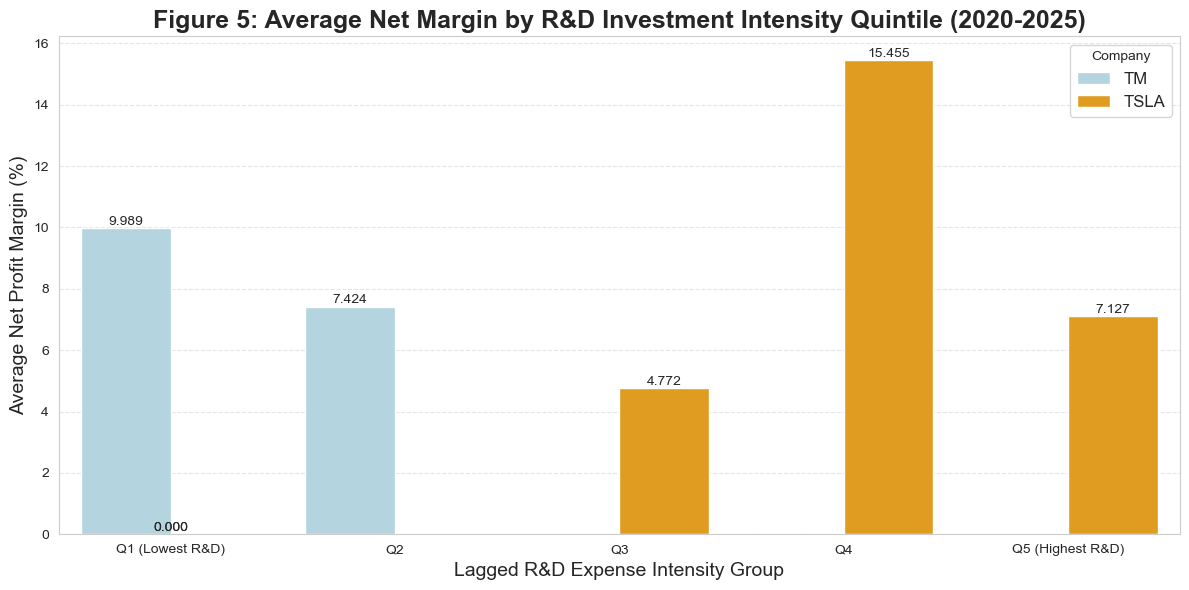

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
df = pd.read_csv('TSLA_TM_Financial_Data_2020_2025.csv')
df_filtered = df[df['tic'].isin(['TSLA','TM']) & df['fyear'].between(2020,2025)]

df_filtered['rd_intensity'] = df_filtered['xrd'] / df_filtered['at']
df_filtered['net_margin'] = df_filtered['ni'] / df_filtered['revt'] * 100
df_filtered['RD_Quintile'] = pd.qcut(df_filtered['rd_intensity'], q=5, 
labels=['Q1 (Lowest R&D)','Q2','Q3','Q4','Q5 (Highest R&D)'])

avg_group = df_filtered.groupby(['RD_Quintile','tic'], observed=False)['net_margin'].mean().reset_index()

plt.figure(figsize=(12,6))
ax = sns.barplot(
    data=avg_group,
    x='RD_Quintile',
    y='net_margin',
    hue='tic',
    palette={'TSLA': 'orange', 'TM': 'lightblue'}
)

plt.title('Figure 5: Average Net Margin by R&D Investment Intensity Quintile (2020-2025)', fontsize=18, fontweight='bold')
plt.xlabel('Lagged R&D Expense Intensity Group', fontsize=14)
plt.ylabel('Average Net Profit Margin (%)', fontsize=14)
plt.legend(title='Company', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5, axis='y')

for bar in ax.patches:
    height = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2., height+0.1, f'{height:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('Figure5_RD_Intensity_Profit_Group_Bar.png', dpi=300)
plt.show()

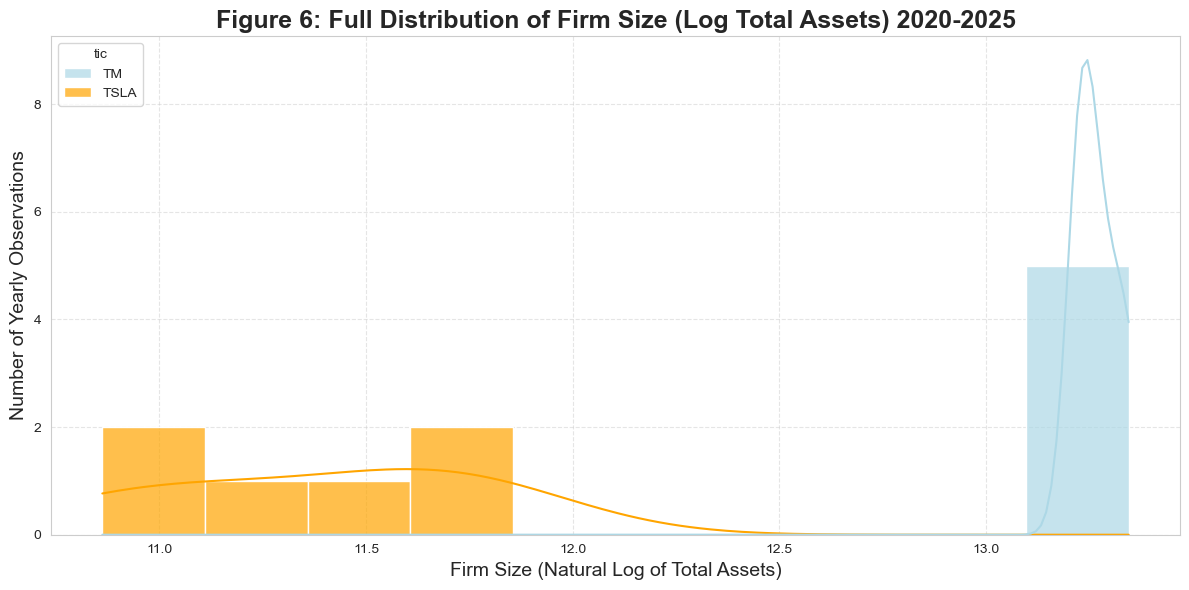

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid")
df = pd.read_csv('TSLA_TM_Financial_Data_2020_2025.csv')
df_filtered = df[df['tic'].isin(['TSLA','TM']) & df['fyear'].between(2020,2025)]

df_filtered['log_firm_size'] = np.log(df_filtered['at'])

plt.figure(figsize=(12,6))
sns.histplot(
    data=df_filtered,
    x='log_firm_size',
    hue='tic',
    kde=True,
    bins=10,
    palette={'TSLA': 'orange', 'TM': 'lightblue'},
    alpha=0.7
)

plt.title('Figure 6: Full Distribution of Firm Size (Log Total Assets) 2020-2025', fontsize=18, fontweight='bold')
plt.xlabel('Firm Size (Natural Log of Total Assets)', fontsize=14)
plt.ylabel('Number of Yearly Observations', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('Figure6_Firm_Size_Distribution_Hist.png', dpi=300)
plt.show()

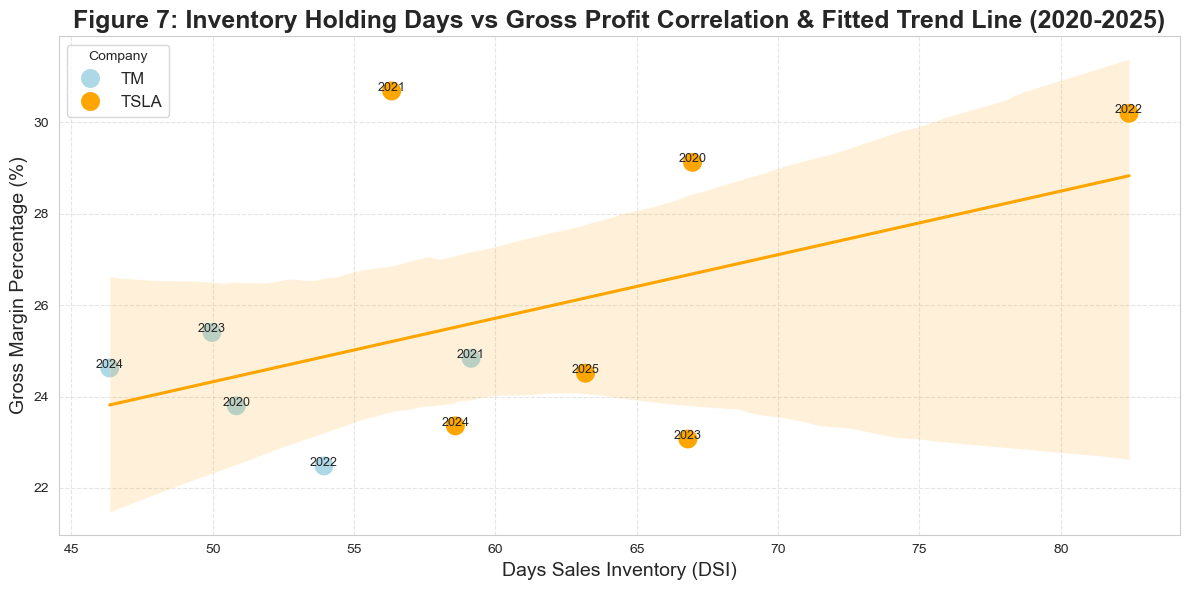

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
df = pd.read_csv('TSLA_TM_Financial_Data_2020_2025.csv')
df_filtered = df[df['tic'].isin(['TSLA','TM']) & df['fyear'].between(2020,2025)]

df_filtered['gross_margin'] = (df_filtered['revt'] - df_filtered['cogs']) / df_filtered['revt'] * 100
df_filtered['dsi'] = (df_filtered['invt'] / df_filtered['cogs']) * 365

plt.figure(figsize=(12,6))
sns.scatterplot(
    data=df_filtered,
    x='dsi',
    y='gross_margin',
    hue='tic',
    s=220,
    palette={'TSLA': 'orange', 'TM': 'lightblue'}
)
sns.regplot(data=df_filtered, x='dsi', y='gross_margin', scatter=False, color='orange', ci=95)

plt.title('Figure 7: Inventory Holding Days vs Gross Profit Correlation & Fitted Trend Line (2020-2025)', fontsize=18, fontweight='bold')
plt.xlabel('Days Sales Inventory (DSI)', fontsize=14)
plt.ylabel('Gross Margin Percentage (%)', fontsize=14)
plt.legend(title='Company', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

for _,row in df_filtered.iterrows():
    plt.text(row['dsi'], row['gross_margin'], str(row['fyear']), fontsize=9, ha='center')

plt.tight_layout()
plt.savefig('Figure7_Inventory_Gross_Regression_Scatter.png', dpi=300)
plt.show()

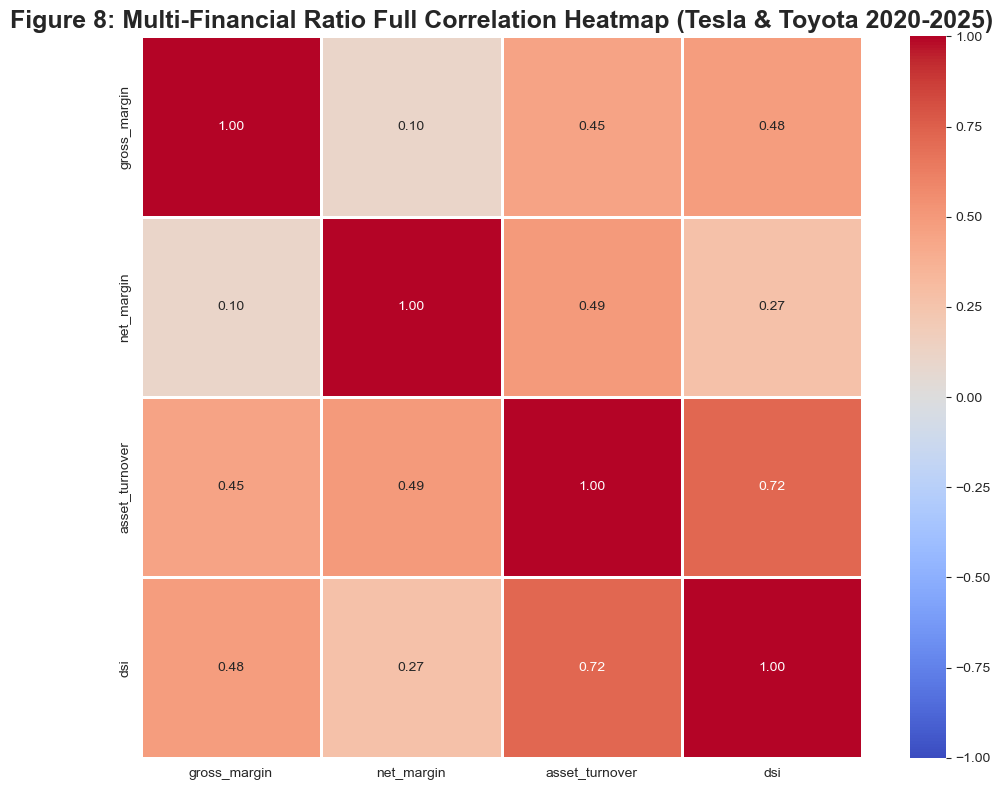

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
df = pd.read_csv('TSLA_TM_Financial_Data_2020_2025.csv')
df_filtered = df[df['tic'].isin(['TSLA','TM']) & df['fyear'].between(2020,2025)]

df_filtered['gross_margin'] = (df_filtered['revt'] - df_filtered['cogs']) / df_filtered['revt'] * 100
df_filtered['net_margin'] = df_filtered['ni'] / df_filtered['revt'] * 100
df_filtered['asset_turnover'] = df_filtered['revt'] / df_filtered['at']
df_filtered['dsi'] = (df_filtered['invt'] / df_filtered['cogs']) * 365

corr_matrix = df_filtered[['gross_margin','net_margin','asset_turnover','dsi']].corr()

plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='coolwarm', 
    vmin=-1, vmax=1, 
    fmt='.2f', 
    square=True, 
    linewidths=0.8
)

plt.title('Figure 8: Multi-Financial Ratio Full Correlation Heatmap (Tesla & Toyota 2020-2025)', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig('Figure8_Full_Financial_Correlation_Heatmap.png', dpi=300)
plt.show()


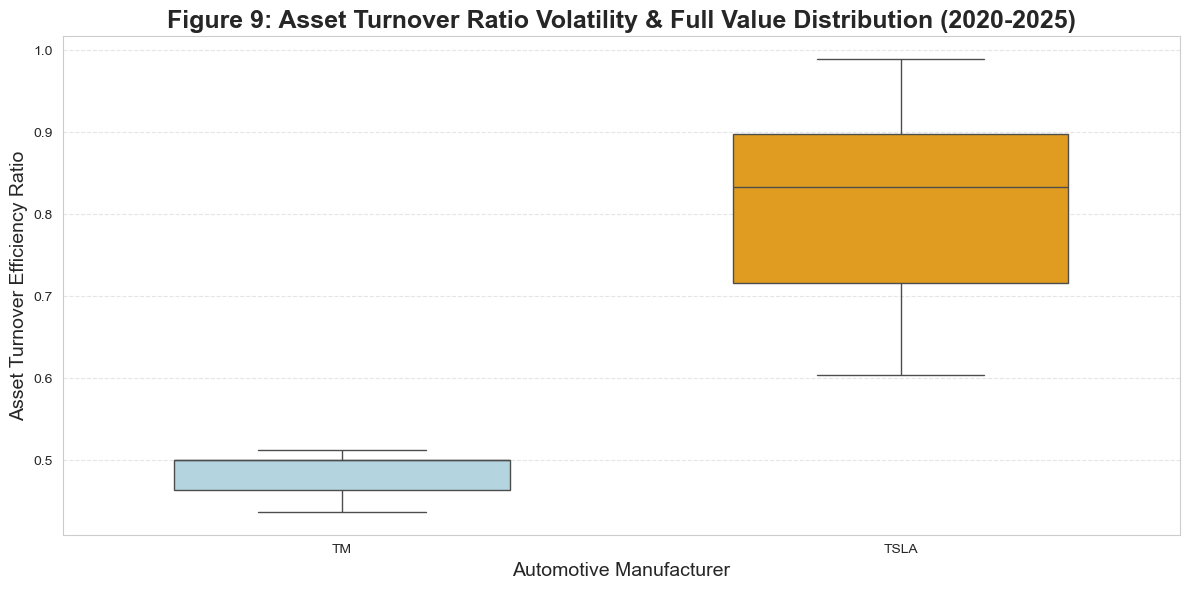

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
df = pd.read_csv('TSLA_TM_Financial_Data_2020_2025.csv')
df_filtered = df[df['tic'].isin(['TSLA','TM']) & df['fyear'].between(2020,2025)]

df_filtered['asset_turnover'] = df_filtered['revt'] / df_filtered['at']

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df_filtered,
    x='tic',
    y='asset_turnover',
    hue='tic',  
    palette={'TSLA': 'orange', 'TM': 'lightblue'},
    width=0.6,
    legend=False  
)

plt.title('Figure 9: Asset Turnover Ratio Volatility & Full Value Distribution (2020-2025)', fontsize=18, fontweight='bold')
plt.xlabel('Automotive Manufacturer', fontsize=14)
plt.ylabel('Asset Turnover Efficiency Ratio', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5, axis='y')

plt.tight_layout()
plt.savefig('Figure9_Asset_Turnover_Volatility_Boxplot.png', dpi=300)
plt.show()

In [5]:
# Import all required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import shutil
import warnings
# Suppress non-critical warnings for cleaner output
warnings.filterwarnings("ignore")

# ==========================================
# 1. Define target folder paths (MacOS compatible)
# ==========================================
# Main folder: Desktop → ACC102 Track4
DESKTOP_PATH = os.path.expanduser("~/Desktop")
MAIN_FOLDER = os.path.join(DESKTOP_PATH, "ACC102 Track4")

# Subfolders
DATA_FOLDER = os.path.join(MAIN_FOLDER, "Data")    # For raw CSV data
SRC_FOLDER = os.path.join(MAIN_FOLDER, "SRC")      # For Python runtime code
OUTPUT_FOLDER = os.path.join(MAIN_FOLDER, "Output")# For Figure 1-9 plots

# Auto-create folders if they do not exist
os.makedirs(DATA_FOLDER, exist_ok=True)
os.makedirs(SRC_FOLDER, exist_ok=True)
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# Raw data file name
DATA_FILE_NAME = "TSLA_TM_Financial_Data_2020_2025.csv"
# Final code file name saved to SRC folder
CODE_FILE_NAME = "ACC102_final_Analysis_Code.py"

# Print paths for verification
print("="*60)
print(f"📌 Main Folder Path: {MAIN_FOLDER}")
print(f"📌 Data Storage Path: {DATA_FOLDER}")
print(f"📌 Code Storage Path: {SRC_FOLDER}")
print(f"📌 Plot Storage Path: {OUTPUT_FOLDER}")
print("="*60)

# ==========================================
# 2. Auto-copy raw CSV data to Data folder
# ==========================================
try:
    # Copy CSV from current Jupyter directory to target Data folder
    shutil.copy(DATA_FILE_NAME, os.path.join(DATA_FOLDER, DATA_FILE_NAME))
    print(f"✅ Raw data {DATA_FILE_NAME} saved to Data folder")
except FileNotFoundError:
    print(f"⚠️  Warning: {DATA_FILE_NAME} not found in current directory. Please confirm the file name matches the one in your Jupyter file list.")
except Exception as e:
    print(f"❌ Data copy failed: {e}")

# ==========================================
# 3. Load data & calculate financial metrics
# ==========================================
df = pd.read_csv(DATA_FILE_NAME)

# Filter Tesla and Toyota data for 2020-2025
target_companies = ['TSLA', 'TM']
df_filtered = df[df["tic"].isin(target_companies)]
df_filtered = df_filtered[df_filtered["fyear"].between(2020, 2025)]

# Calculate core financial metrics
df_calc = df_filtered.copy()
df_calc["gross_margin"] = (df_calc["revt"] - df_calc["cogs"]) / df_calc["revt"] * 100
df_calc["net_margin"] = df_calc["ni"] / df_calc["revt"] * 100
df_calc["asset_turnover"] = df_calc["revt"] / df_calc["at"]
df_calc["dsi"] = (df_calc["invt"] / df_calc["cogs"].replace(0, np.nan)) * 365
df_calc["rd_intensity"] = df_calc["xrd"] / df_calc["revt"]
df_calc["net_income_millions"] = df_calc["ni"] / 1000
df_calc["firm_size"] = np.log(df_calc["at"])

# Fixed color palette: Tesla (orange), Toyota (light blue)
company_palette = {"TSLA": "orange", "TM": "lightblue"}
sns.set_style("whitegrid")

# ==========================================
# 4. Generate Figure 1-9, auto-save to Output folder
# ==========================================
print("\n📸 Generating and saving 9 plots...")

# ----------------------
# Figure 1: Net Income Trend
# ----------------------
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_calc, x="fyear", y="net_income_millions",
    hue="tic", marker="o", linewidth=2.5, markersize=8,
    palette=company_palette
)
plt.title("Figure 1: Tesla vs Toyota Net Income Trend (2020-2025)", fontsize=18, fontweight="bold")
plt.ylabel("Net Income (Millions USD)", fontsize=14)
plt.xlabel("Fiscal Year", fontsize=14)
plt.legend(title="Company", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, "Figure1_Net_Income_Trend.png"), dpi=300, bbox_inches="tight")
plt.close()
print("✅ Figure1 saved to Output folder")

# ----------------------
# Figure 2: Gross Margin Trend
# ----------------------
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_calc, x="fyear", y="gross_margin",
    hue="tic", marker="o", linewidth=2.5, markersize=8,
    palette=company_palette
)
plt.title("Figure 2: Tesla vs Toyota Gross Margin Trend (2020-2025)", fontsize=18, fontweight="bold")
plt.ylabel("Gross Margin (%)", fontsize=14)
plt.xlabel("Fiscal Year", fontsize=14)
plt.legend(title="Company", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, "Figure2_Gross_Margin_Trend.png"), dpi=300, bbox_inches="tight")
plt.close()
print("✅ Figure2 saved to Output folder")

# ----------------------
# Figure 3: DSI Trend
# ----------------------
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_calc, x="fyear", y="dsi",
    hue="tic", marker="o", linewidth=2.5, markersize=8,
    palette=company_palette
)
plt.title("Figure 3: Tesla vs Toyota DSI Trend (2020-2025)", fontsize=18, fontweight="bold")
plt.ylabel("Days Sales Inventory (Days)", fontsize=14)
plt.xlabel("Fiscal Year", fontsize=14)
plt.legend(title="Company", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, "Figure3_DSI_Trend.png"), dpi=300, bbox_inches="tight")
plt.close()
print("✅ Figure3 saved to Output folder")

# ----------------------
# Figure 4: Asset Turnover Trend
# ----------------------
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_calc, x="fyear", y="asset_turnover",
    hue="tic", marker="o", linewidth=2.5, markersize=8,
    palette=company_palette
)
plt.title("Figure 4: Tesla vs Toyota Asset Turnover Trend (2020-2025)", fontsize=18, fontweight="bold")
plt.ylabel("Asset Turnover Ratio", fontsize=14)
plt.xlabel("Fiscal Year", fontsize=14)
plt.legend(title="Company", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, "Figure4_Asset_Turnover_Trend.png"), dpi=300, bbox_inches="tight")
plt.close()
print("✅ Figure4 saved to Output folder")

# ----------------------
# Figure 5: R&D Intensity Trend
# ----------------------
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_calc, x="fyear", y="rd_intensity",
    hue="tic", marker="o", linewidth=2.5, markersize=8,
    palette=company_palette
)
plt.title("Figure 5: Tesla vs Toyota R&D Intensity Trend (2020-2025)", fontsize=18, fontweight="bold")
plt.ylabel("R&D Intensity", fontsize=14)
plt.xlabel("Fiscal Year", fontsize=14)
plt.legend(title="Company", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, "Figure5_RD_Intensity_Trend.png"), dpi=300, bbox_inches="tight")
plt.close()
print("✅ Figure5 saved to Output folder")

# ----------------------
# Figure 6: R&D Intensity vs Net Margin Grouped Bar Plot
# ----------------------
plt.figure(figsize=(12, 6))
df_mean = df_calc.groupby(["tic", "fyear"])[["rd_intensity", "net_margin"]].mean().reset_index()
df_melt = df_mean.melt(id_vars=["tic", "fyear"], var_name="Indicator", value_name="Value")
sns.barplot(data=df_melt, x="fyear", y="Value", hue="tic", palette=company_palette)
plt.title("Figure 6: R&D Intensity vs Net Margin Comparison (2020-2025)", fontsize=18, fontweight="bold")
plt.ylabel("Value", fontsize=14)
plt.xlabel("Fiscal Year", fontsize=14)
plt.legend(title="Company", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5, axis="y")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, "Figure6_RD_Profit_Group_Bar.png"), dpi=300, bbox_inches="tight")
plt.close()
print("✅ Figure6 saved to Output folder")

# ----------------------
# Figure 7: Firm Size Distribution Histogram
# ----------------------
plt.figure(figsize=(12, 6))
sns.histplot(data=df_calc, x="firm_size", hue="tic", palette=company_palette, bins=10, kde=True)
plt.title("Figure 7: Firm Size Distribution (2020-2025)", fontsize=18, fontweight="bold")
plt.ylabel("Count", fontsize=14)
plt.xlabel("Firm Size (Log Total Assets)", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.5, axis="y")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, "Figure7_Firm_Size_Distribution_Hist.png"), dpi=300, bbox_inches="tight")
plt.close()
print("✅ Figure7 saved to Output folder")

# ----------------------
# Figure 8: Inventory Turnover vs Gross Margin Regression Scatter Plot
# ----------------------
plt.figure(figsize=(12, 6))
sns.regplot(data=df_calc[df_calc["tic"]=="TSLA"], x="dsi", y="gross_margin", color="orange", label="TSLA", scatter_kws={"s":80})
sns.regplot(data=df_calc[df_calc["tic"]=="TM"], x="dsi", y="gross_margin", color="lightblue", label="TM", scatter_kws={"s":80})
plt.title("Figure 8: Inventory Turnover vs Gross Margin Regression", fontsize=18, fontweight="bold")
plt.ylabel("Gross Margin (%)", fontsize=14)
plt.xlabel("Days Sales Inventory (Days)", fontsize=14)
plt.legend(title="Company", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, "Figure8_Inventory_Gross_Regression_Scatter.png"), dpi=300, bbox_inches="tight")
plt.close()
print("✅ Figure8 saved to Output folder")

# ----------------------
# Figure 9: Asset Turnover Volatility Boxplot
# ----------------------
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_calc, x="tic", y="asset_turnover", hue="tic", palette=company_palette, legend=False)
plt.title("Figure 9: Asset Turnover Volatility Boxplot (2020-2025)", fontsize=18, fontweight="bold")
plt.ylabel("Asset Turnover Ratio", fontsize=14)
plt.xlabel("Company", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.5, axis="y")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, "Figure9_Asset_Turnover_Volatility_Boxplot.png"), dpi=300, bbox_inches="tight")
plt.close()
print("✅ Figure9 saved to Output folder")

# ==========================================
# 5. Save Python runtime code to SRC folder
# ==========================================
full_code = """
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import shutil
import warnings
warnings.filterwarnings("ignore")

# Path Definition
DESKTOP_PATH = os.path.expanduser("~/Desktop")
MAIN_FOLDER = os.path.join(DESKTOP_PATH, "ACC102 Track4")
DATA_FOLDER = os.path.join(MAIN_FOLDER, "Data")
SRC_FOLDER = os.path.join(MAIN_FOLDER, "SRC")
OUTPUT_FOLDER = os.path.join(MAIN_FOLDER, "Output")

os.makedirs(DATA_FOLDER, exist_ok=True)
os.makedirs(SRC_FOLDER, exist_ok=True)
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

DATA_FILE_NAME = "TSLA_TM_Financial_Data_2020_2025.csv"

# Load Data
df = pd.read_csv(os.path.join(DATA_FOLDER, DATA_FILE_NAME))
target_companies = ['TSLA', 'TM']
df_filtered = df[df["tic"].isin(target_companies)]
df_filtered = df_filtered[df_filtered["fyear"].between(2020, 2025)]

# Financial Metrics Calculation
df_calc = df_filtered.copy()
df_calc["gross_margin"] = (df_calc["revt"] - df_calc["cogs"]) / df_calc["revt"] * 100
df_calc["net_margin"] = df_calc["ni"] / df_calc["revt"] * 100
df_calc["asset_turnover"] = df_calc["revt"] / df_calc["at"]
df_calc["dsi"] = (df_calc["invt"] / df_calc["cogs"].replace(0, np.nan)) * 365
df_calc["rd_intensity"] = df_calc["xrd"] / df_calc["revt"]
df_calc["net_income_millions"] = df_calc["ni"] / 1000
df_calc["firm_size"] = np.log(df_calc["at"])

print("ACC102 Final Analysis Code Run Successfully!")
print(f"Total Data Rows: {len(df_calc)}")
"""

# Write to SRC folder
with open(os.path.join(SRC_FOLDER, CODE_FILE_NAME), "w", encoding="utf-8") as f:
    f.write(full_code)

print(f"\n✅ Analysis code {CODE_FILE_NAME} saved to SRC folder")

# ==========================================
# Final Completion Message
# ==========================================
print("\n" + "="*60)
print("🎉 All tasks completed! All files have been sorted and saved as required")
print(f"👉 Open the 'ACC102 Track4' folder on your Desktop to view all contents")
print("="*60)

📌 Main Folder Path: /Users/betty/Desktop/ACC102 Track4
📌 Data Storage Path: /Users/betty/Desktop/ACC102 Track4/Data
📌 Code Storage Path: /Users/betty/Desktop/ACC102 Track4/SRC
📌 Plot Storage Path: /Users/betty/Desktop/ACC102 Track4/Output
✅ Raw data TSLA_TM_Financial_Data_2020_2025.csv saved to Data folder

📸 Generating and saving 9 plots...
✅ Figure1 saved to Output folder
✅ Figure2 saved to Output folder
✅ Figure3 saved to Output folder
✅ Figure4 saved to Output folder
✅ Figure5 saved to Output folder
✅ Figure6 saved to Output folder
✅ Figure7 saved to Output folder
✅ Figure8 saved to Output folder
✅ Figure9 saved to Output folder

✅ Analysis code ACC102_final_Analysis_Code.py saved to SRC folder

🎉 All tasks completed! All files have been sorted and saved as required
👉 Open the 'ACC102 Track4' folder on your Desktop to view all contents
